
# Triadic Cell Notebook v13
## Energy-weighted decoding, margin gating, trust-over-coverage

v12 exposed a turn:

- bank-native decoding helped a little for BTR
- but it also helped the weak baseline
- raw accuracy moved only slightly
- the strongest separation was not accuracy alone

The real separator in v12 was:

- **slot divergence**
- **bank margin**
- **structured slot energy**

So v13 stops pushing raw recall and turns toward **trust gating**.

## What v13 asks

Instead of:
> can we force one more point of raw accuracy?

it asks:
> can the triadic machine produce **more trustworthy recalls**
> by using slot energy and decoder margin to decide when to answer at all?

That means v13 measures:

1. **energy-weighted bank decoding**
2. **hybrid score = cosine × slot energy**
3. **margin-gated recall**
4. **coverage vs accuracy**
5. **accepted-only precision**

This is the first notebook that treats memory readout as:
- not just classification
- but **classification under trust**


In [1]:

from __future__ import annotations

from dataclasses import dataclass
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.


In [2]:

@dataclass
class AddressedTriadicState:
    coherence: float = 0.72
    latent: np.ndarray = None
    readout: np.ndarray = None

    def __post_init__(self):
        if self.latent is None:
            self.latent = np.array([0.20, 0.35, 0.50, 0.15], dtype=float)
        if self.readout is None:
            self.readout = np.zeros(2, dtype=float)


In [3]:

class KeyedMemoryBank:
    def __init__(self, width: int = 4, leak: float = 0.015):
        self.width = width
        self.leak = float(leak)

        self.keys = np.array([
            [1.0, 0.2, 0.0, 0.0],
            [0.0, 1.0, 0.2, 0.0],
            [0.2, 0.0, 1.0, 0.2],
            [0.0, 0.2, 0.0, 1.0],
        ], dtype=float)
        self.keys = self.keys / np.linalg.norm(self.keys, axis=1, keepdims=True)

        self.slots = np.zeros((4, width), dtype=float)

    @staticmethod
    def _softmax(x: np.ndarray, temp: float = 1.0) -> np.ndarray:
        z = (x - np.max(x)) / max(temp, 1e-8)
        e = np.exp(z)
        return e / np.sum(e)

    def address(self, query: np.ndarray, content_mix: float = 0.15) -> np.ndarray:
        q = query / (np.linalg.norm(query) + 1e-8)
        key_scores = self.keys @ q

        if np.any(self.slots > 0):
            slot_norms = np.linalg.norm(self.slots, axis=1, keepdims=True) + 1e-8
            slot_dirs = self.slots / slot_norms
            content_scores = slot_dirs @ q
        else:
            content_scores = np.zeros_like(key_scores)

        scores = (1.0 - content_mix) * key_scores + content_mix * content_scores
        return self._softmax(scores, temp=0.08)

    def read(self, weights: np.ndarray) -> np.ndarray:
        return weights @ self.slots

    def write(self, weights: np.ndarray, value: np.ndarray, strength: float, topk: int = 2):
        self.slots *= (1.0 - self.leak)
        idx = np.argsort(weights)[::-1][:topk]
        masked = np.zeros_like(weights)
        masked[idx] = weights[idx]
        if masked.sum() > 0:
            masked = masked / masked.sum()
        for i in range(self.slots.shape[0]):
            self.slots[i] = np.clip(self.slots[i] + strength * masked[i] * value, 0.0, 1.0)
        return masked.copy()

    def slot_energy(self) -> np.ndarray:
        return self.slots.mean(axis=1)


In [4]:

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))


def rank_against_library(vec: np.ndarray, library: np.ndarray):
    sims = np.array([cosine_similarity(vec, p) for p in library], dtype=float)
    order = np.argsort(sims)[::-1]
    top1_idx = int(order[0])
    top1 = float(sims[order[0]])
    top2 = float(sims[order[1]]) if len(order) > 1 else 0.0
    return sims, top1_idx, top1, top1 - top2


def rank_against_bank(vec: np.ndarray, templates: np.ndarray, energies: np.ndarray, energy_power: float = 1.0):
    sims = np.array([cosine_similarity(vec, t) for t in templates], dtype=float)
    weighted = sims * np.power(np.clip(energies, 1e-8, None), energy_power)
    order = np.argsort(weighted)[::-1]
    top1_idx = int(order[0])
    top1 = float(weighted[order[0]])
    top2 = float(weighted[order[1]]) if len(order) > 1 else 0.0
    return weighted, top1_idx, top1, top1 - top2


In [5]:

class TriadicCellV13:
    def __init__(self, B: float, T: float, R: float):
        self.B = float(B)
        self.T = float(T)
        self.R = float(R)
        self.W_readout = np.array([[1.0, 0.2, 0.0, -0.3],
                                   [0.0, 0.8, -0.4, 0.6]], dtype=float)
        self.W_query = np.array([[1.0, 0.0, 0.3, 0.0],
                                 [0.0, 1.0, 0.0, 0.4],
                                 [0.3, 0.0, 1.0, 0.0],
                                 [0.0, 0.4, 0.0, 1.0]], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def _query(self, latent: np.ndarray) -> np.ndarray:
        raw_query = self.W_query @ latent
        return raw_query / (np.linalg.norm(raw_query) + 1e-8)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = self._query(cue)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(self, s: AddressedTriadicState, drive_vec: np.ndarray, bank: KeyedMemoryBank,
             write_enabled: bool = True, target_slot: int | None = None,
             novelty_threshold: float = 0.10, template_pull: float = 0.35,
             templates: np.ndarray | None = None):
        query = self._query(s.latent)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        load = np.linalg.norm(s.readout) + 0.2 * np.linalg.norm(recalled)
        coherence_restore = 0.05 * self.B * (0.84 - s.coherence)
        coherence_burn = 0.07 * self.T * (1.0 - self.B) + 0.008 * load
        coherence = float(np.clip(s.coherence + coherence_restore - coherence_burn, 0.0, 1.0))

        composite_target = 0.72 * drive_vec + 0.28 * recalled
        follow = 0.20 * self.B * self.T * coherence * (composite_target - s.latent)
        static_drag = 0.04 * (1.0 - self.T) * (s.latent - np.array([0.20, 0.35, 0.50, 0.15]))
        unsupported_loss = 0.14 * self.T * (1.0 - self.B) * s.latent
        latent = self._clip(s.latent + follow - static_drag - unsupported_loss)

        delta_vec = np.abs(latent - s.latent)

        support = self.B * self.T * self.R * coherence
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)

        shell_decay = (0.18 * (1.0 - self.T) + 0.12 * (1.0 - self.R)) * s.readout
        readout = self._clip(0.82 * s.readout + 2.25 * support * projected - shell_decay)

        base_write_strength = float(0.60 * support * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        weights = np.zeros(4, dtype=float) if target_slot is not None else addr.copy()
        if target_slot is not None:
            weights[target_slot] = 1.0

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            write_value = np.clip((1.0 - template_pull) * latent + template_pull * templates[target_slot], 0.0, 1.0)

        if write_enabled:
            bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(coherence=coherence, latent=latent, readout=readout)
        return next_state


class PlainTRBaselineV13:
    def __init__(self):
        self.W_readout = np.array([[1.0, 0.2, 0.0, -0.3],
                                   [0.0, 0.8, -0.4, 0.6]], dtype=float)

    @staticmethod
    def _clip(x):
        return np.clip(x, 0.0, 1.0)

    def probe(self, cue: np.ndarray, bank: KeyedMemoryBank):
        query = cue / (np.linalg.norm(cue) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)
        return addr.copy(), recalled.copy()

    def step(self, s: AddressedTriadicState, drive_vec: np.ndarray, bank: KeyedMemoryBank,
             write_enabled: bool = True, target_slot: int | None = None,
             novelty_threshold: float = 0.10, template_pull: float = 0.0,
             templates: np.ndarray | None = None):
        query = s.latent / (np.linalg.norm(s.latent) + 1e-8)
        addr = bank.address(query, content_mix=0.15)
        recalled = bank.read(addr)

        coherence = float(np.clip(s.coherence - 0.08 - 0.02 * np.linalg.norm(s.readout), 0.0, 1.0))
        composite_target = 0.72 * drive_vec + 0.28 * recalled
        latent = self._clip(s.latent + 0.10 * coherence * (composite_target - s.latent) - 0.18 * s.latent)

        delta_vec = np.abs(latent - s.latent)
        projected = self.W_readout @ delta_vec
        projected = np.maximum(projected, 0.0)
        readout = self._clip(0.65 * s.readout + 1.35 * projected - 0.35 * s.readout)

        base_write_strength = float(0.08 * readout.mean())
        novelty = max(0.0, 1.0 - cosine_similarity(recalled, drive_vec) - novelty_threshold)
        write_strength = base_write_strength * novelty

        weights = np.zeros(4, dtype=float) if target_slot is not None else addr.copy()
        if target_slot is not None:
            weights[target_slot] = 1.0

        write_value = latent.copy()
        if target_slot is not None and templates is not None and template_pull > 0.0:
            write_value = np.clip((1.0 - template_pull) * latent + template_pull * templates[target_slot], 0.0, 1.0)

        if write_enabled:
            bank.write(weights, write_value, write_strength, topk=1 if target_slot is not None else 2)

        next_state = AddressedTriadicState(coherence=coherence, latent=latent, readout=readout)
        return next_state


In [6]:

patterns = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)


In [7]:

def partial_cue(pattern: np.ndarray, mask_prob: float = 0.5, noise: float = 0.04) -> np.ndarray:
    cue = pattern.copy()
    mask = rng.random(pattern.shape[0]) < mask_prob
    cue[mask] = 0.0
    cue += rng.normal(0.0, noise, size=cue.shape[0])
    return np.clip(cue, 0.0, 1.0)


def store_patterns(model, bank: KeyedMemoryBank, cycles_per_pattern: int = 18, reset_per_slot: bool = False, template_pull: float = 0.0):
    state = AddressedTriadicState()
    for slot_idx, p in enumerate(patterns):
        if reset_per_slot:
            state = AddressedTriadicState()
        for _ in range(cycles_per_pattern):
            drive = np.clip(p + rng.normal(0.0, 0.03, size=p.shape[0]), 0.0, 1.0)
            state = model.step(state, drive, bank, write_enabled=True, target_slot=slot_idx, novelty_threshold=0.10,
                               template_pull=template_pull, templates=patterns)
    return bank.slot_energy().copy(), bank.slots.copy()


def probe_patterns(model, bank: KeyedMemoryBank, bank_templates: np.ndarray, energy_power: float = 1.0, trials_per_pattern: int = 24):
    energies = np.clip(bank.slot_energy(), 1e-8, None)
    rows = []
    for idx, p in enumerate(patterns):
        for _ in range(trials_per_pattern):
            cue = partial_cue(p, mask_prob=0.5, noise=0.04)
            addr, recalled = model.probe(cue, bank)

            sims_proto, pred_proto, top1_proto, margin_proto = rank_against_library(recalled, patterns)
            sims_bank, pred_bank, top1_bank, margin_bank = rank_against_library(recalled, bank_templates)
            weighted_bank, pred_weighted, top1_weighted, margin_weighted = rank_against_bank(recalled, bank_templates, energies, energy_power=energy_power)

            rows.append({
                "target_slot": idx,
                "pred_raw": int(np.argmax(addr)),
                "pred_proto": pred_proto,
                "pred_bank": pred_bank,
                "pred_weighted_bank": pred_weighted,
                "sim_raw": cosine_similarity(recalled, p),
                "proto_margin": margin_proto,
                "bank_margin": margin_bank,
                "weighted_bank_margin": margin_weighted,
            })
    return pd.DataFrame(rows)


def gated_metrics(df: pd.DataFrame, pred_col: str, margin_col: str, thresholds=(0.00, 0.02, 0.05, 0.10, 0.15)):
    rows = []
    for t in thresholds:
        accepted = df[df[margin_col] >= t].copy()
        coverage = len(accepted) / len(df)
        acc = float((accepted[pred_col] == accepted["target_slot"]).mean()) if len(accepted) else np.nan
        rows.append({"threshold": t, "coverage": coverage, "accepted_accuracy": acc})
    return pd.DataFrame(rows)


In [8]:

def run_condition(model_name: str, triadic: bool, reset_per_slot: bool, template_pull: float):
    model = TriadicCellV13(1.0, 1.0, 1.0) if triadic else PlainTRBaselineV13()
    bank = KeyedMemoryBank(width=4, leak=0.015)

    slot_energy, templates = store_patterns(model, bank, cycles_per_pattern=18, reset_per_slot=reset_per_slot, template_pull=template_pull)
    probe_df = probe_patterns(model, bank, templates, energy_power=1.0, trials_per_pattern=24)

    summary = {
        "model": model_name,
        "storage_mode": "reset" if reset_per_slot else "sequential",
        "template_pull": template_pull,
        "raw_accuracy": float((probe_df["pred_raw"] == probe_df["target_slot"]).mean()),
        "proto_accuracy": float((probe_df["pred_proto"] == probe_df["target_slot"]).mean()),
        "bank_accuracy": float((probe_df["pred_bank"] == probe_df["target_slot"]).mean()),
        "weighted_bank_accuracy": float((probe_df["pred_weighted_bank"] == probe_df["target_slot"]).mean()),
        "raw_similarity": float(probe_df["sim_raw"].mean()),
        "mean_proto_margin": float(probe_df["proto_margin"].mean()),
        "mean_bank_margin": float(probe_df["bank_margin"].mean()),
        "mean_weighted_bank_margin": float(probe_df["weighted_bank_margin"].mean()),
        "slot_divergence": float(np.std(slot_energy)),
    }
    return summary, probe_df, slot_energy, templates

conditions = [
    ("BTR", True, False, 0.0),
    ("BTR", True, True, 0.0),
    ("BTR", True, True, 0.35),
    ("Plain TR baseline", False, True, 0.0),
]

runs = []
details = {}

for model_name, triadic, reset_per_slot, template_pull in conditions:
    summary, probe_df, slot_energy, templates = run_condition(model_name, triadic, reset_per_slot, template_pull)
    runs.append(summary)
    key = (model_name, "reset" if reset_per_slot else "sequential", template_pull)
    details[key] = {"probe": probe_df, "slot_energy": slot_energy, "templates": templates}

summary_df = pd.DataFrame(runs)
summary_df


,model,storage_mode,template_pull,raw_accuracy,proto_accuracy,bank_accuracy,weighted_bank_accuracy,raw_similarity,mean_proto_margin,mean_bank_margin,mean_weighted_bank_margin,slot_divergence
0,BTR,sequential,0.00,0.541667,0.541667,0.541667,0.385417,0.619052,0.147247,0.226325,0.014396,0.023231
1,BTR,reset,0.00,0.500000,0.489583,0.520833,0.250000,0.635740,0.308370,0.209345,0.013460,0.012521
2,BTR,reset,0.35,0.552083,0.552083,0.562500,0.250000,0.656733,0.433509,0.320889,0.005928,0.004419
3,Plain TR baseline,reset,0.00,0.489583,0.385417,0.510417,0.250000,0.583969,0.160857,0.035831,0.001224,0.000627



## Accuracy comparison


In [9]:

summary_df[["model", "storage_mode", "template_pull", "raw_accuracy", "proto_accuracy", "bank_accuracy", "weighted_bank_accuracy"]]


,model,storage_mode,template_pull,raw_accuracy,proto_accuracy,bank_accuracy,weighted_bank_accuracy
0,BTR,sequential,0.00,0.541667,0.541667,0.541667,0.385417
1,BTR,reset,0.00,0.500000,0.489583,0.520833,0.250000
2,BTR,reset,0.35,0.552083,0.552083,0.562500,0.250000
3,Plain TR baseline,reset,0.00,0.489583,0.385417,0.510417,0.250000


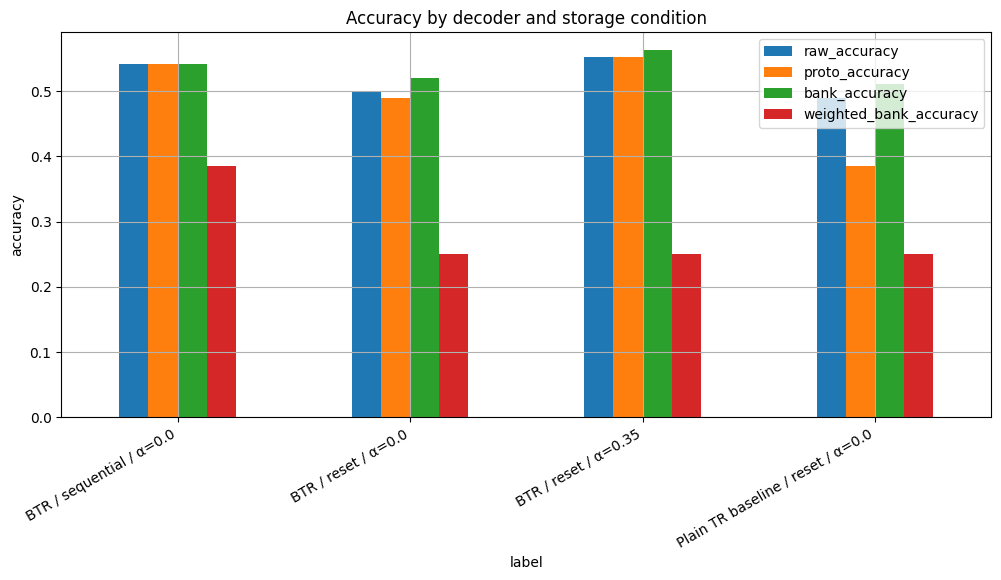

In [10]:

plot_df = summary_df.copy()
plot_df["label"] = plot_df["model"] + " / " + plot_df["storage_mode"] + " / α=" + plot_df["template_pull"].astype(str)
plot_df = plot_df.set_index("label")[["raw_accuracy", "proto_accuracy", "bank_accuracy", "weighted_bank_accuracy"]]
plot_df.plot(kind="bar", figsize=(12, 5))
plt.title("Accuracy by decoder and storage condition")
plt.ylabel("accuracy")
plt.xticks(rotation=30, ha="right")
plt.show()



## Margin and divergence comparison


In [11]:

summary_df[["model", "storage_mode", "template_pull", "mean_proto_margin", "mean_bank_margin", "mean_weighted_bank_margin", "slot_divergence"]]


,model,storage_mode,template_pull,mean_proto_margin,mean_bank_margin,mean_weighted_bank_margin,slot_divergence
0,BTR,sequential,0.00,0.147247,0.226325,0.014396,0.023231
1,BTR,reset,0.00,0.308370,0.209345,0.013460,0.012521
2,BTR,reset,0.35,0.433509,0.320889,0.005928,0.004419
3,Plain TR baseline,reset,0.00,0.160857,0.035831,0.001224,0.000627



## Gated accuracy curves

This is the real turn in v13:
not "always answer", but "answer when the manifold is decisive".


In [12]:

gated_tables = {}
for key, item in details.items():
    model, mode, alpha = key
    gated_tables[key] = gated_metrics(item["probe"], pred_col="pred_weighted_bank", margin_col="weighted_bank_margin")

for key, gdf in gated_tables.items():
    model, mode, alpha = key
    print(f"{model} / {mode} / α={alpha}")
    display(gdf)


BTR / sequential / α=0.0


,threshold,coverage,accepted_accuracy
0,0.00,1.000000,0.385417
1,0.02,0.197917,0.631579
2,0.05,0.000000,NaN
3,0.10,0.000000,NaN
4,0.15,0.000000,NaN


BTR / reset / α=0.0


,threshold,coverage,accepted_accuracy
0,0.00,1.000000,0.250000
1,0.02,0.291667,0.392857
2,0.05,0.000000,NaN
3,0.10,0.000000,NaN
4,0.15,0.000000,NaN


BTR / reset / α=0.35


,threshold,coverage,accepted_accuracy
0,0.00,1.0,0.25
1,0.02,0.0,NaN
2,0.05,0.0,NaN
3,0.10,0.0,NaN
4,0.15,0.0,NaN


Plain TR baseline / reset / α=0.0


,threshold,coverage,accepted_accuracy
0,0.00,1.0,0.25
1,0.02,0.0,NaN
2,0.05,0.0,NaN
3,0.10,0.0,NaN
4,0.15,0.0,NaN


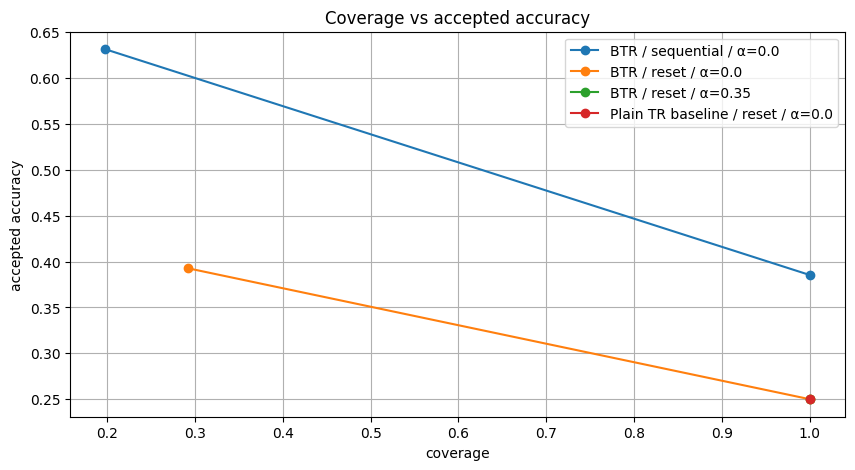

In [13]:

plt.figure(figsize=(10, 5))
for key, gdf in gated_tables.items():
    model, mode, alpha = key
    label = f"{model} / {mode} / α={alpha}"
    plt.plot(gdf["coverage"], gdf["accepted_accuracy"], marker="o", label=label)

plt.title("Coverage vs accepted accuracy")
plt.xlabel("coverage")
plt.ylabel("accepted accuracy")
plt.legend(loc="best")
plt.show()



## Slot energies


In [14]:

energy_df = pd.DataFrame({
    f"{model} / {mode} / α={alpha}": details[(model, mode, alpha)]["slot_energy"]
    for model, mode, alpha in details.keys()
}, index=[f"slot_{i}" for i in range(4)])
energy_df


,BTR / sequential / α=0.0,BTR / reset / α=0.0,BTR / reset / α=0.35,Plain TR baseline / reset / α=0.0
slot_0,0.019491,0.019036,0.004605,0.000540
slot_1,0.077044,0.008026,0.001934,0.000346
slot_2,0.072910,0.003350,0.001770,0.000271
slot_3,0.045065,0.035889,0.012638,0.001815


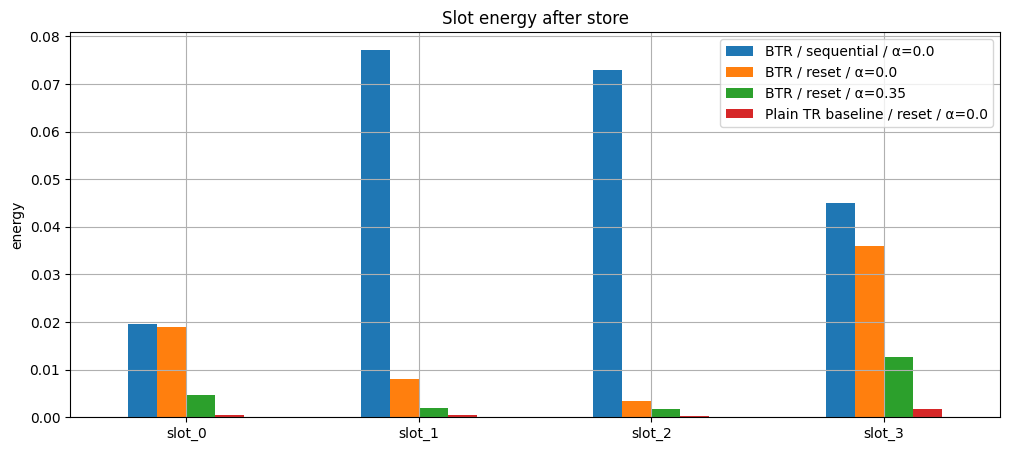

In [15]:

energy_df.plot(kind="bar", figsize=(12, 5))
plt.title("Slot energy after store")
plt.ylabel("energy")
plt.xticks(rotation=0)
plt.show()



## Read the result

The key question is now:

- does **weighted bank decoding** beat raw decoding?
- do **margin gates** let BTR keep higher accepted precision at usable coverage?
- does **template anchoring** help BTR more than it helps the baseline?
- does **reset-per-slot** clean up the slot manifold?

If yes, then the machine may not need higher raw recall first.
It may need **trust-shaped readout**:
answer less often, but answer on cleaner manifolds.
